# Acreción utilizando las correcciones del código de Claude
### Ahora aparece un factor de eficiencia en la acreción $\lambda$ y desaparece el factor de acreción 

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from PBHBeta import constants
import functionscorr as fn_comp
import jax
import jax.numpy as jnp
from scipy.optimize import brentq   
import equinox as eqx
import jax.lax as lax
from diffrax import diffeqsolve, ODETerm, Tsit5, PIDController, SaveAt

In [2]:

def calcular_envolvente_sbb(M_tot, omega_sbb):
    """Calcula y devuelve la envolvente de todas las restricciones SBB base."""
    limpiar_memoria()
    fn_comp.Betas_DM(M_tot, omega_sbb)
    fn_comp.Betas_BBN(M_tot, omega_sbb)
    fn_comp.Betas_SD(M_tot, omega_sbb)
    fn_comp.Betas_CMB_AN(M_tot, omega_sbb)
    fn_comp.Betas_GRB(M_tot, omega_sbb)
    fn_comp.Betas_Reio(M_tot, omega_sbb)
    fn_comp.Betas_LSP(M_tot, omega_sbb)
    return fn_comp.get_Betas_full(M_tot)

def formato_grafica(titulo):
    """Aplica formato estándar a las gráficas."""
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$M_i$ [g]', fontsize=13)
    plt.ylabel(r'$\beta$', fontsize=13)
    #plt.title(titulo, fontsize=14)
    plt.xlim(1.0, 1e20)
    plt.ylim(1e-35, 1e0)
    plt.legend(fontsize=10, loc='upper right', ncol=2)
    plt.grid(False, which="both", ls=":", alpha=0.5)
    plt.tight_layout()

1. Evaluando restricción exclusiva de Materia Oscura (DM)...
Calculando dinámica para lambda = 0.5...
Calculando dinámica para lambda = 1.0...
Calculando dinámica para lambda = 1.5...


/tmp/ipykernel_9958/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


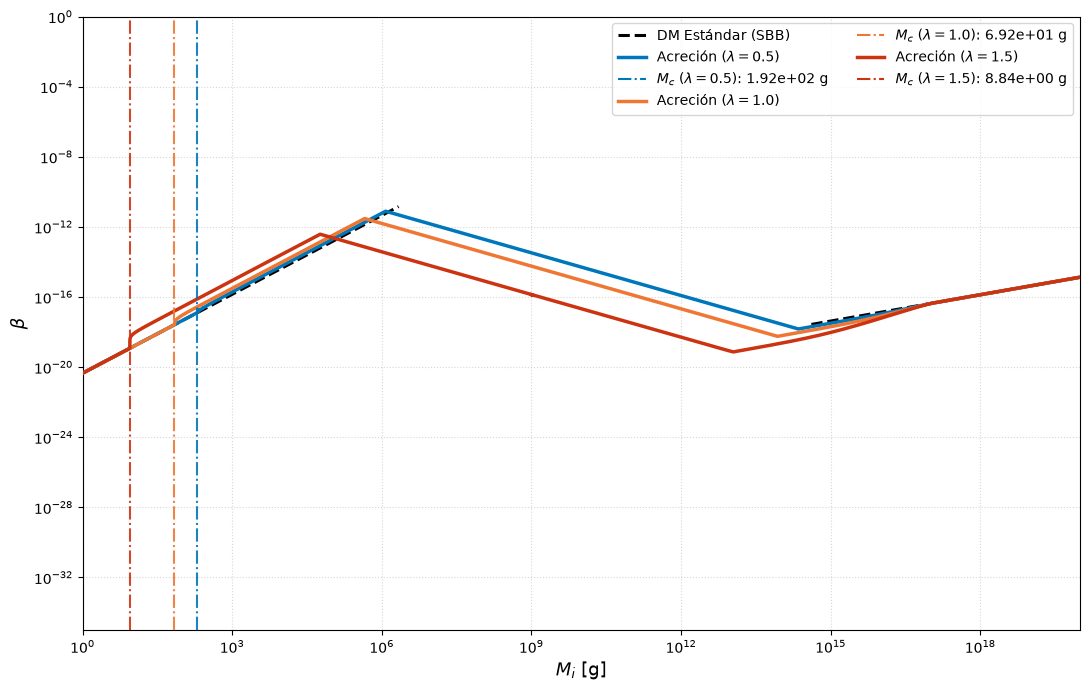

In [3]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    # Limpiamos el resto por seguridad aunque no se usen aquí
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
    
def encontrar_masa_critica_num(N_fin, a_star, lam_efectivo):
    """
    Encuentra la masa exacta de transición usando el integrador JAX principal.
    """
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, lam=lam_efectivo)
        
        Mf_g = float(M_f_tot_jnp[0])
        # Si log10(Mf/Mi) es negativo, dominó evaporación. Si es positivo, dominó acreción.
        return float(np.log10(Mf_g / Mi_g))

    try:
        # Límite ajustado a -2.0 (0.01 g) para garantizar que el PBH se evapore y brentq tenga signos opuestos
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontró masa crítica para lambda={lam_efectivo}. Error: {e}")
        return None

def graficar_solo_DM():
    print("1. Evaluando restricción exclusiva de Materia Oscura (DM)...")
    
    # Empezamos desde 1e-5 para evitar cortes a la izquierda
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000) 
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    
    omega_sbb = 1.0 / 3.0  
    N_fin = 25.0
    a_star = 0.0
    
    # Calcular línea base SBB 
    limpiar_memoria()
    fn_comp.Betas_DM(M_tot, omega_sbb)
    beta_dm_sbb = np.array(fn_comp.constraints.betas_DM_tot)
    
    plt.figure(figsize=(11, 7))
    b_sbb_plot = np.where(beta_dm_sbb == fn_comp.constants.ev1, np.nan, beta_dm_sbb)
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='DM Estándar (SBB)', zorder=2)
    
    lam_list = [0.5, 1.0, 1.5]
    colores = ['#0077BB', '#EE7733', '#CC3311']
    
    for idx, lam in enumerate(lam_list):
        print(f"Calculando dinámica para lambda = {lam}...")
        
        # 1. Hallar Masa Crítica primero
        Mc = encontrar_masa_critica_num(N_fin, a_star, lam)
        
        # 2. Integración de masas usando JAX
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam)
        
        # 3. Corrimiento estricto
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), beta_dm_sbb)
        
        # 4. Trazar el espectro
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2.5, label=rf'Acreción ($\lambda={lam}$)', zorder=3)
        
        # 5. Trazar la pared vertical de la transición
        if Mc:
            # Traza una línea desde abajo hasta tapar el hueco de transición
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            # Etiqueta invisible en la gráfica, pero visible en la leyenda para mostrar el valor exacto
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($\lambda={lam}$): {Mc:.2e} g')

    formato_grafica(rf'Cota de Materia Oscura (DM) con acreción ($N_{{fin}}={N_fin}, a_*={a_star}$)')
    plt.show()

if __name__ == "__main__":
    graficar_solo_DM()


2. Evaluando constraints completas barriendo N_fin...
   -> Integrando N_fin = 15.0...
   -> Integrando N_fin = 20.0...
   -> Integrando N_fin = 25.0...
   -> Integrando N_fin = 30.0...


/tmp/ipykernel_9958/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


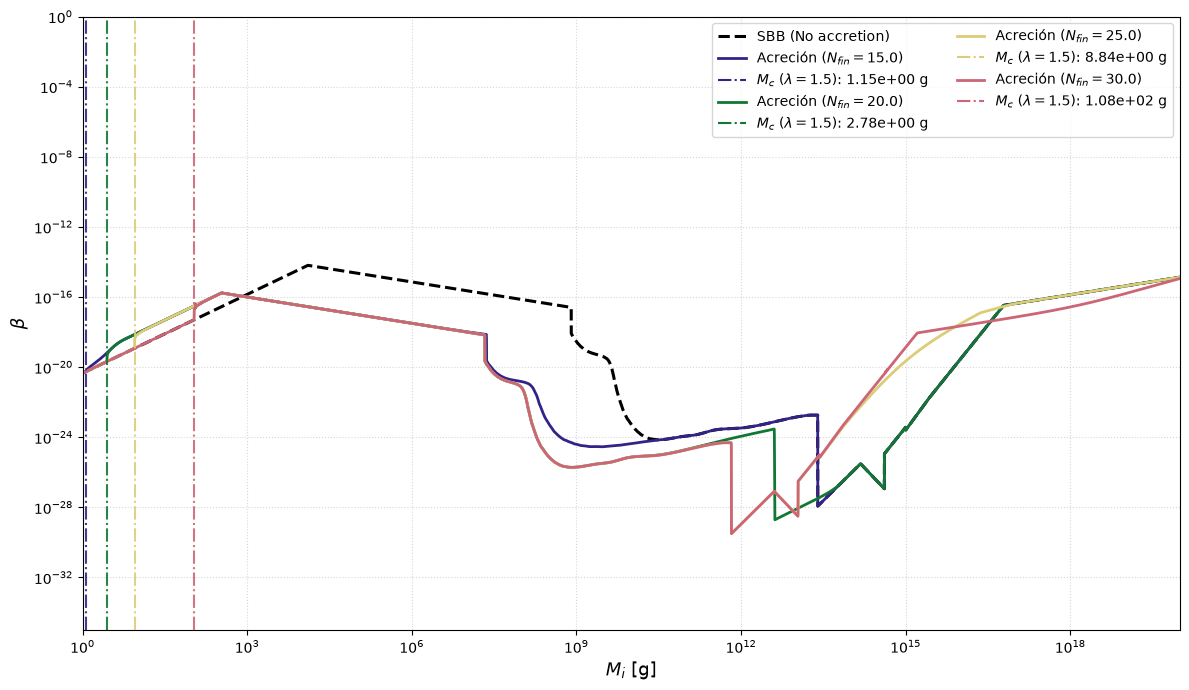

In [21]:

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    # Limpiamos el resto por seguridad aunque no se usen aquí
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
# ====================================================================
# 2. BARRIDO EN E-FOLDS (N_fin) PARA TODAS LAS RESTRICCIONES
# ====================================================================
def encontrar_masa_critica_num(N_fin, a_star, lam_efectivo):
    """
    Encuentra la masa exacta de transición usando el integrador JAX principal.
    """
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, lam=lam_efectivo)
        
        Mf_g = float(M_f_tot_jnp[0])
        # Si log10(Mf/Mi) es negativo, dominó evaporación. Si es positivo, dominó acreción.
        return float(np.log10(Mf_g / Mi_g))

    try:
        # Límite ajustado a -2.0 (0.01 g) para garantizar que el PBH se evapore y brentq tenga signos opuestos
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontró masa crítica para eFolds={N_fin}. Error: {e}")
        return None
    
def graficar_efolds():
    print("2. Evaluando constraints completas barriendo N_fin...")
    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0
    
    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)
    
    plt.figure(figsize=(12, 7))
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')
    
    # Fijamos lambda supercrítico para observar el límite del horizonte
    lam = 1.5 
    a_star = 0.0
    N_list = [15.0, 20.0, 25.0, 30.0]
    colores = ['#332288', '#117733', '#DDCC77', '#CC6677']
    
    for idx, N_fin in enumerate(N_list):
        print(f"   -> Integrando N_fin = {N_fin}...")
        Mc = encontrar_masa_critica_num(N_fin, a_star, lam)
        
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)
        
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2, label=rf'Acreción ($N_{{fin}}={N_fin}$)')
        
        if Mc:
            # Traza una línea desde abajo hasta tapar el hueco de transición
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            # Etiqueta invisible en la gráfica, pero visible en la leyenda para mostrar el valor exacto
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($\lambda={lam}$): {Mc:.2e} g')
            
    formato_grafica(rf'Restricciones en variando el número de efolds($\lambda={lam}$)')
    plt.savefig('efoldsarray.pdf')
    plt.show()
    

if __name__ == "__main__":
    graficar_efolds()

3. Evaluando constraints completas barriendo el Espín (a_*)...
   -> Integrando a_* = 0.0...
   -> Integrando a_* = 0.7...
   -> Integrando a_* = 0.9...
   -> Integrando a_* = 0.99...


/tmp/ipykernel_9958/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


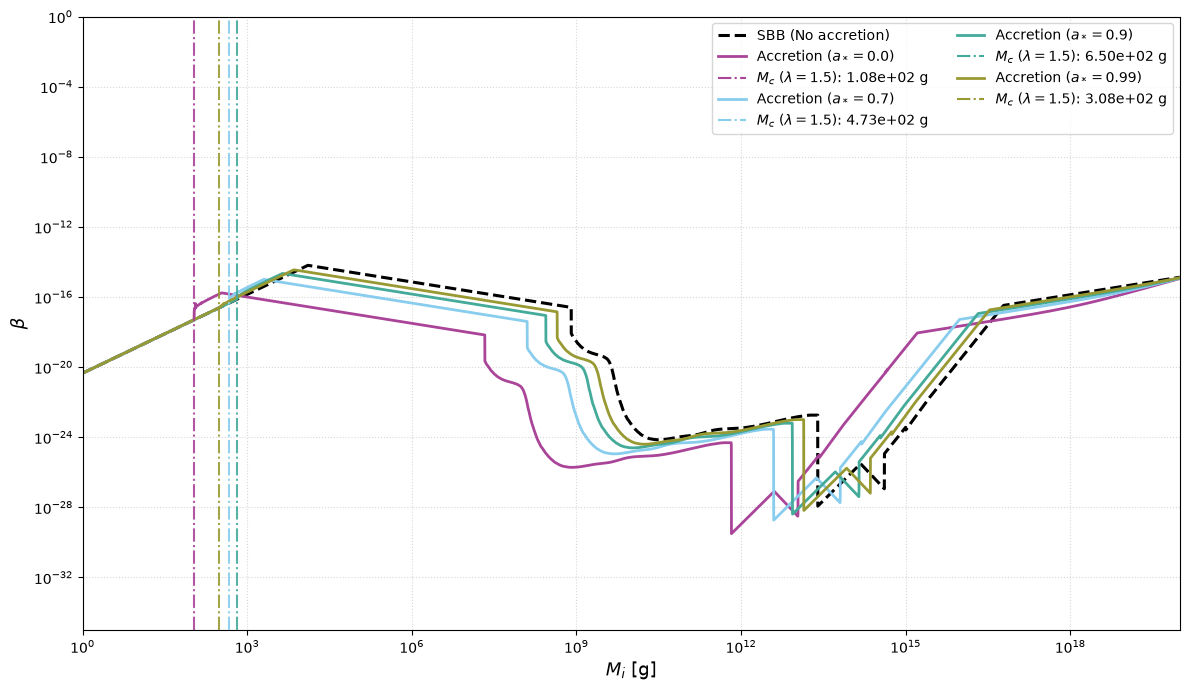

In [20]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    # Limpiamos el resto por seguridad aunque no se usen aquí
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
# ====================================================================
# 3. BARRIDO EN ESPÍN (a_star) PARA TODAS LAS RESTRICCIONES
# ====================================================================
def encontrar_masa_critica_num(N_fin, a_star, lam_efectivo):
    """
    Encuentra la masa exacta de transición usando el integrador JAX principal.
    """
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, lam=lam_efectivo)
        
        Mf_g = float(M_f_tot_jnp[0])
        # Si log10(Mf/Mi) es negativo, dominó evaporación. Si es positivo, dominó acreción.
        return float(np.log10(Mf_g / Mi_g))

    try:
        # Límite ajustado a -2.0 (0.01 g) para garantizar que el PBH se evapore y brentq tenga signos opuestos
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontró masa crítica para Spin={a_star}. Error: {e}")
        return None
    
def graficar_espin():
    print("3. Evaluando constraints completas barriendo el Espín (a_*)...")
    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0
    
    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)
    
    plt.figure(figsize=(12, 7))
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')
    
    # Usar un lambda que es supercrítico para a=0, pero subcrítico para a=0.99
    lam = 1.5 
    N_fin = 30.0
    a_list = [0.0, 0.7, 0.9, 0.99]
    colores = ['#AA4499', '#88CCEE', '#44AA99', '#999933']
    
    for idx, a_star in enumerate(a_list):
        print(f"   -> Integrando a_* = {a_star}...")
        Mc = encontrar_masa_critica_num(N_fin, a_star, lam)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)
        
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2, label=rf'Accretion ($a_*={a_star}$)')
        if Mc:
            # Traza una línea desde abajo hasta tapar el hueco de transición
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            # Etiqueta invisible en la gráfica, pero visible en la leyenda para mostrar el valor exacto
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($\lambda={lam}$): {Mc:.2e} g')

    formato_grafica(rf'Transición de régimen según Espín inicial ($\lambda={lam}, N_{{fin}}={N_fin}$)')
    plt.savefig('spinarray.pdf')
    plt.show()    
if __name__ == "__main__":
    graficar_espin()


4. Evaluando constraints completas barriendo Lambda...
   -> Integrando lambda = 0.5...
   -> Integrando lambda = 1.0...
   -> Integrando lambda = 1.4...
   -> Integrando lambda = 1.8...


/tmp/ipykernel_9958/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


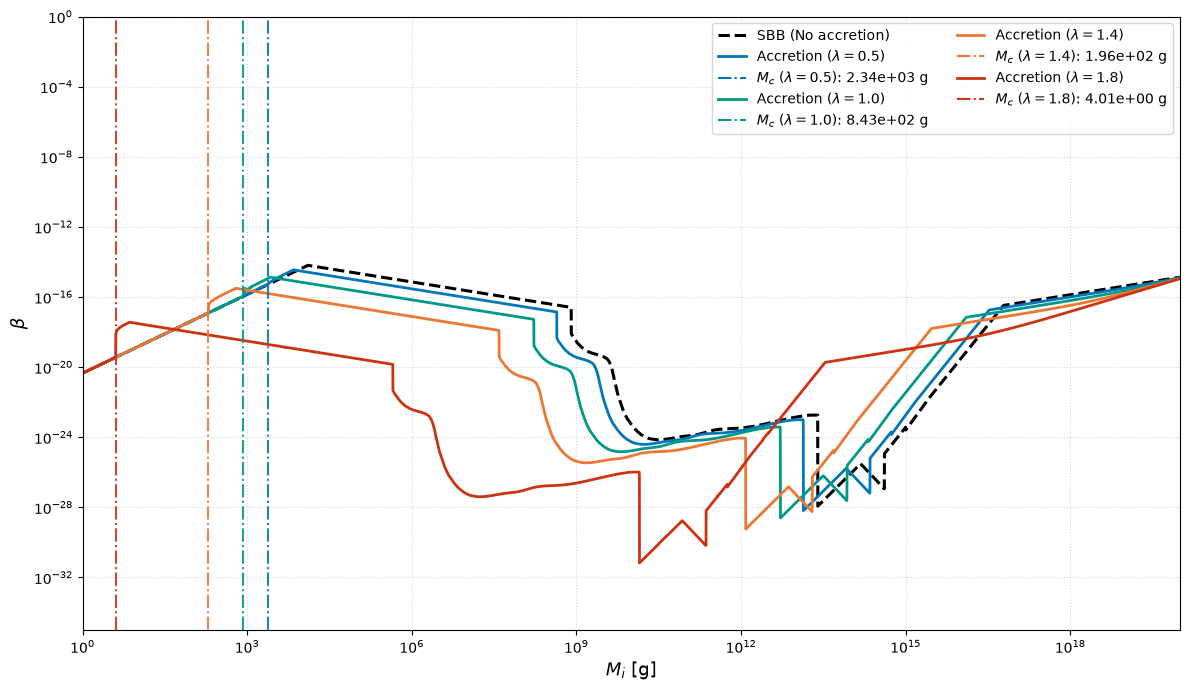

In [8]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    # Limpiamos el resto por seguridad aunque no se usen aquí
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
# ====================================================================
# 4. BARRIDO EN EFICIENCIA DE ACRECIÓN (lambda) PARA TODAS LAS RESTRICCIONES
# ====================================================================
def encontrar_masa_critica_num(N_fin, a_star, lam_efectivo):
    """
    Encuentra la masa exacta de transición usando el integrador JAX principal.
    """
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, lam=lam_efectivo)
        
        Mf_g = float(M_f_tot_jnp[0])
        # Si log10(Mf/Mi) es negativo, dominó evaporación. Si es positivo, dominó acreción.
        return float(np.log10(Mf_g / Mi_g))

    try:
        # Límite ajustado a -2.0 (0.01 g) para garantizar que el PBH se evapore y brentq tenga signos opuestos
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontró masa crítica para lambda={lam_efectivo}. Error: {e}")
        return None
    
def graficar_lambda():
    print("4. Evaluando constraints completas barriendo Lambda...")
    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0
    
    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)
    
    plt.figure(figsize=(12, 7))
    plt.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')
    
    N_fin = 30.0
    a_star = 0.0
    lam_list = [0.5, 1.0, 1.4, 1.8]
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']
    
    for idx, lam in enumerate(lam_list):
        print(f"   -> Integrando lambda = {lam}...")
        Mc = encontrar_masa_critica_num(N_fin, a_star, lam)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)
        
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        plt.plot(M_tot, b_plot, color=colores[idx], lw=2, label=rf'Accretion ($\lambda={lam}$)')
        if Mc:
            plt.axvline(x=Mc, color=colores[idx], linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            plt.plot([], [], color=colores[idx], linestyle='-.', label=rf'$M_c$ ($\lambda={lam}$): {Mc:.2e} g')

    formato_grafica(rf'Desplazamiento según eficiencia $\lambda$ ($N_{{fin}}={N_fin}, a_*={a_star}$)')
    plt.savefig('lamarray.pdf')
    plt.show()
    
if __name__ == "__main__":
    graficar_lambda()

4. Evaluando constraints completas barriendo Lambda...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscorr.py:340: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)
/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscorr.py:543: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)


   -> Integrando lambda = 0.5...
   -> Integrando lambda = 1.0...
   -> Integrando lambda = 1.4...
   -> Integrando lambda = 1.8...
   -> Integrando lambda = 2.2...


/tmp/ipykernel_9058/2438531416.py:23: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, which="both", ls=":", alpha=0.5)


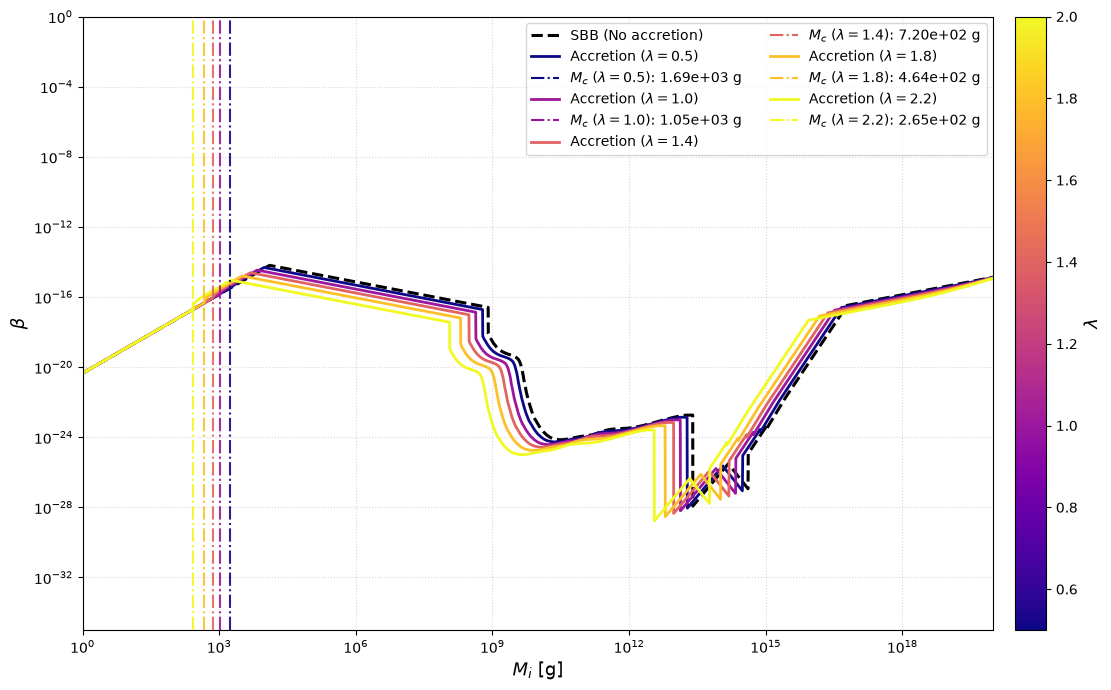

In [3]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def encontrar_masa_critica_num(N_fin, a_star, lam_efectivo):
    """
    Encuentra la masa exacta de transición usando el integrador JAX principal.
    """
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(Mi_jnp, N_fin, a_star, lam=lam_efectivo)
        
        Mf_g = float(M_f_tot_jnp[0])
        # Si log10(Mf/Mi) es negativo, dominó evaporación. Si es positivo, dominó acreción.
        return float(np.log10(Mf_g / Mi_g))

    try:
        # Límite ajustado a -2.0 (0.01 g) para garantizar que el PBH se evapore y brentq tenga signos opuestos
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontró masa crítica para lambda={lam_efectivo}. Error: {e}")
        return None

# ====================================================================
# 4. BARRIDO EN EFICIENCIA DE ACRECIÓN (lambda) CON COLORBAR
# ====================================================================

def graficar_lambda():
    print("4. Evaluando constraints completas barriendo Lambda...")
    
    # Asegúrate de importar o definir calcular_envolvente_sbb y formato_grafica
    # asumo que ya están en tu código original.
    
    M_tot = fn_comp.put_M_array(1.0, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0
    
    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB (No accretion)')
    
    N_fin = 30.0
    a_star = 0.9
    
    # Lista de lambdas a evaluar
    lam_list = [0.5, 1.0, 1.4, 1.8, 2.2]
    
    # ---------------------------------------------------------
    # CONFIGURACIÓN DEL MAPA DE COLORES (COLORBAR)
    # ---------------------------------------------------------
    cmap = plt.get_cmap('plasma')  # 'plasma', 'viridis', o 'inferno' quedan muy bien
    norm = mcolors.Normalize(vmin=0.5, vmax=2.0) # Forzamos el rango de 0.5 a 2.0
    
    for lam in lam_list:
        print(f"   -> Integrando lambda = {lam}...")
        
        # Extraer el color exacto para el valor de lambda actual
        color_lam = cmap(norm(lam))
        
        Mc = encontrar_masa_critica_num(N_fin, a_star, lam)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam)
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)
        
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        
        # Trazar usando el color dinámico. 
        # (Opcional: puedes quitar la etiqueta de Acreción de aquí si el colorbar ya lo explica)
        ax.plot(M_tot, b_plot, color=color_lam, lw=2, label=rf'Accretion ($\lambda={lam}$)')
        
        if Mc:
            ax.axvline(x=Mc, color=color_lam, linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
            ax.plot([], [], color=color_lam, linestyle='-.', label=rf'$M_c$ ($\lambda={lam}$): {Mc:.2e} g')

    # ---------------------------------------------------------
    # INSERCIÓN DEL COLORBAR EN LA GRÁFICA
    # ---------------------------------------------------------
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # Requerimiento técnico de Matplotlib
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$\lambda$', fontsize=13)
    
    # Aplicar tu formato habitual
    formato_grafica(rf'Desplazamiento según eficiencia $\lambda$ ($N_{{fin}}={N_fin}, a_*={a_star}$)')
    plt.savefig('lamarray.pdf')
    plt.show()
    
if __name__ == "__main__":
    graficar_lambda()

1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar (SBB)...
3/4 - JAX: Calculando dinámica de acreción y aplicando shift...
4/4 - Procesando gráfica comparativa...


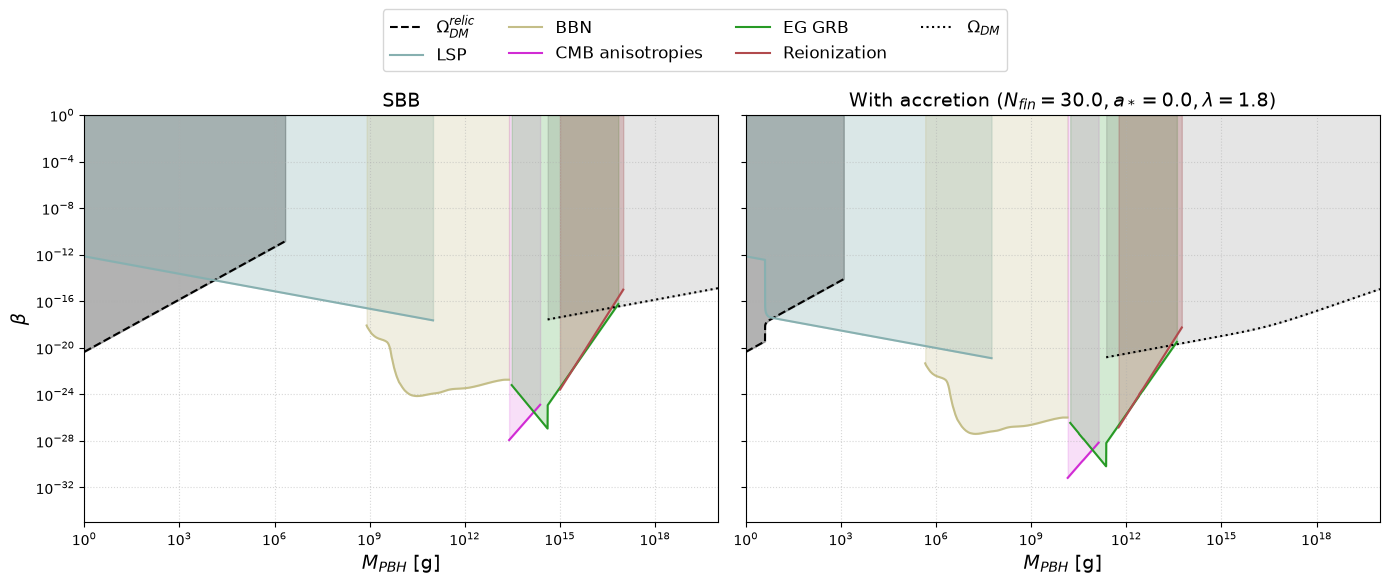

In [15]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    # Limpiamos el resto por seguridad aunque no se usen aquí
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
    fn_comp.constraints.betas_LSP_tot = []

def clean_beta(b):
    """Enmascara los valores inválidos (ev1) con NaN para que matplotlib no trace caídas falsas."""
    return np.where(b == constants.ev1, np.nan, b)

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_comp.put_M_array(1e-5, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0/3.0 # Las restricciones estándar SBB se mapean en radiación
    N_fin = 30.00
    a_star = 0.0
    lam = 1.8 # Autovalor de acreción
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar (SBB)...")
    limpiar_memoria()
    
    # Calculamos las envolventes base
    fn_comp.Betas_DM(M_tot, omega)
    fn_comp.Betas_LSP(M_tot, omega)
    fn_comp.Betas_BBN(M_tot, omega)
    fn_comp.Betas_CMB_AN(M_tot, omega)
    fn_comp.Betas_GRB(M_tot, omega)
    fn_comp.Betas_Reio(M_tot, omega)

    # Extraemos las matrices completas SBB (incluyen valores ev1 en los huecos)
    b_dm_std = np.array(fn_comp.constraints.betas_DM_tot)
    b_lsp_std = np.array(fn_comp.constraints.betas_LSP_tot)
    b_bbn_std = np.array(fn_comp.constraints.betas_BBN_tot)
    b_cmb_std = np.array(fn_comp.constraints.betas_CMB_AN_tot)
    b_grb_std = np.array(fn_comp.constraints.betas_GRB_tot)
    b_reio_std = np.array(fn_comp.constraints.betas_Reio_tot)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX) Y CORRIMIENTO EXACTO
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción y aplicando shift...")
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), float(a_star), lam=lam)
    
    # Estabilizamos el ruido numérico para asegurar masa creciente
    M_f_tot = np.maximum.accumulate(np.array(M_f_tot_jnp))
    mu_tot = M_f_tot / M_tot
    
    # Aplicamos el corrimiento (shift) a cada matriz por separado
    b_dm_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_dm_std)
    b_lsp_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_lsp_std)
    b_bbn_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_bbn_std)
    b_cmb_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_cmb_std)
    b_grb_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_grb_std)
    b_reio_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_reio_std)

    # Filtro exclusivo de Materia Oscura (Remueve los PBHs atrapados a mitad del N_fin)
    #M_c = fn_comp.calcular_masa_critica_transicion(float(a_star))
    #mask_bug_dm = (M_tot > M_c) & (M_f_tot < 1000.0)
    #b_dm_acc[mask_bug_dm] = constants.ev1

    # Separación visual de Materia Oscura en Reliquias (línea dashed) y Macroscópicos (línea dotted)
    mask_relic_std = M_tot <= 1e11 * constants.M_pl_g
    mask_macro_std = M_tot > 4.1e14
    b_relic_std = np.where(mask_relic_std, b_dm_std, constants.ev1)
    b_macro_std = np.where(mask_macro_std, b_dm_std, constants.ev1)

    mask_relic_acc = M_f_tot <= 1e11 * constants.M_pl_g
    mask_macro_acc = M_f_tot > 4.1e14
    b_relic_acc = np.where(mask_relic_acc, b_dm_acc, constants.ev1)
    b_macro_acc = np.where(mask_macro_acc, b_dm_acc, constants.ev1)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    def plot_y_sombrear(ax, y_arr, color, label, linestyle='-', alpha_fill=0.3):
        y_clean = clean_beta(y_arr)
        mask = ~np.isnan(y_clean)
        if np.any(mask):
            # Matplotlib mapeará x=M_tot de manera global y saltará los NaNs
            line, = ax.plot(M_tot, y_clean, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(M_tot, y_clean, 1.0, where=mask, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("SBB", fontsize=14)
    plot_y_sombrear(ax1, b_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, b_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, b_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, b_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, b_grb_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    plot_y_sombrear(ax1, b_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, b_macro_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    ax2.set_title(rf"With accretion ($N_{{fin}} = {N_fin}, a_* = {a_star}, \lambda={lam}$)", fontsize=14)
    plot_y_sombrear(ax2, b_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, b_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, b_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, b_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, b_grb_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    plot_y_sombrear(ax2, b_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, b_macro_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1.0, 1e20)
        ax.set_ylim(1e-35, 1e0) # Corregido: plt.ylim(1e-35, 0) no es válido en escala logarítmica
        ax.grid(True, which='both', ls=':', alpha=0.5)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL ---
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
               ncol=4, fontsize=12, frameon=True)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.79)
    plt.savefig('constraintsaccret.pdf')
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()

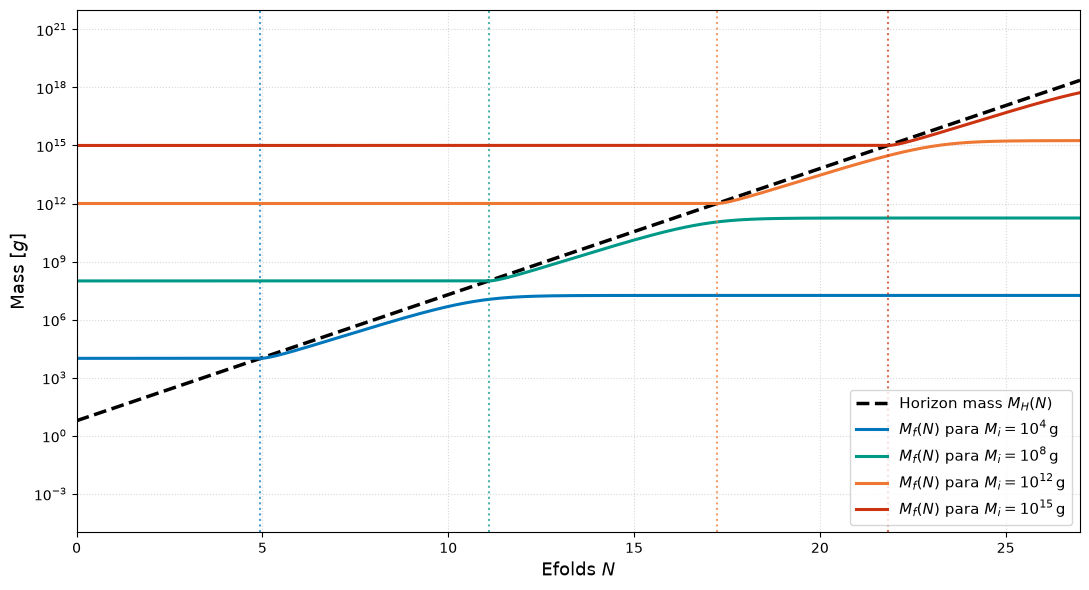

In [13]:
@eqx.filter_jit
def trayectoria_pbh_vs_horizonte(Mi_val_g, N_fin, a_star, lam=2.5, N_puntos=1000):
    # Constantes
    M_pl_GeV = 1.22089e19
    M_pl_g = 2.17645e-5
    H_end_GeV = 4.44e13 
    
    M_i_pl = Mi_val_g / M_pl_g
    H_end_pl = H_end_GeV / M_pl_GeV

    M_end_pl = 1.0 / H_end_pl
    N_ini = (2.0 / 3.0) * jnp.log(jnp.maximum(M_i_pl / M_end_pl, 1.0))
    a_star_safe = jnp.clip(a_star, 0.0, 0.999)

    # ---------------------------------------------------------
    # Parámetros del Campo Escalar
    # ---------------------------------------------------------
    n_scalar = 100.0 
    mu_pl = n_scalar * H_end_pl 
    rho_end_inf_pl = (3.0 * H_end_pl**2.0) / (8.0 * jnp.pi)
    phi_ini_pl = jnp.sqrt(2.0 * rho_end_inf_pl / (mu_pl**2.0 + 9.0 * H_end_pl**2.0 / 4.0))

    # Factores de espín para la acreción (reduce captura geométrica)
    raiz_espin = jnp.sqrt(1.0 - a_star_safe**2.0)
    factor_espin_acc = ((1.0 + raiz_espin) / 2.0)**2.0
    lambda_eff_base = lam * factor_espin_acc

    # Factores de Kerr para la evaporación térmica
    factor_T_kerr = (2.0 * raiz_espin) / (1.0 + raiz_espin)
    factor_Area_kerr = 0.5 * (1.0 + raiz_espin)
    factor_evap_kerr = (factor_T_kerr**4.0) * factor_Area_kerr

    def Hubble(N):
        return H_end_pl * jnp.exp(-1.5 * N)
        
    def rho_inf_field_env(N):
        return 0.5 * (phi_ini_pl * mu_pl)**2 * jnp.exp(-3.0 * N)

    def vector_field_log(N, u, args):
        # Derivada nula si N < N_ini
        du_dN_cero = 0.0
        
        H_val = Hubble(N)
        M_H_actual = 1.0 / H_val
        
        # 1. Blindaje causal estricto
        u_H = jnp.log(M_H_actual)
        u_safe = jnp.clip(u, -1.0, u_H) 
        
        M_actual = jnp.exp(u_safe)
        
        # Variable adimensional de la física causal
        x = M_actual / M_H_actual
        
        # ---------------------------------------------------------
        # Físicas Acopladas al Campo Escalar
        # ---------------------------------------------------------
        rho_phi = rho_inf_field_env(N)
        rho_crit = 3.0 * H_val**2.0 / (8.0 * jnp.pi)
        Omega_phi = rho_phi / rho_crit
        
        z = 2.0 * M_actual * mu_pl
        S_onda = (z**2.0) / (1.0 + z**2.0)
        
        # 2. Dinámica de Acreción de Bondi Modificada
        lambda_eff_total = lambda_eff_base * S_onda
        dlnM_dN_acc = 3.0 * lambda_eff_total * x * jnp.maximum(1.0 - x, 0.0) * Omega_phi
        
        # 3. Dinámica de Evaporación de Hawking-Kerr
        dM_dt_evap_pl = - (1.0 / (3.0 * jnp.maximum(M_actual**2.0, 1.0))) * factor_evap_kerr
        dlnM_dN_evap = (dM_dt_evap_pl / H_val) / M_actual
        
        # 4. Suma neta y Transición suave
        factor_apagado = 0.5 * (1.0 + jnp.tanh(u_safe * 3.0))
        du_dN_val = (dlnM_dN_acc + dlnM_dN_evap) * factor_apagado
        
        # Congelamiento si toca el horizonte o colapsa a reliquia
        du_dN_val = jnp.where(x >= 0.999, 0.0, du_dN_val)
        du_dN_val = jnp.where(u_safe < 0.0, 0.0, du_dN_val)
        
        # Activar la evolución únicamente cuando N >= N_ini
        return jnp.where(N < N_ini, du_dN_cero, du_dN_val)

    # Malla temporal completa
    ts_eval = jnp.linspace(0.0, N_fin, N_puntos)
    saveat = SaveAt(ts=ts_eval)
    
    term = ODETerm(vector_field_log)
    solver = Tsit5()
    stepsize_controller = PIDController(rtol=1e-5, atol=1e-5, jump_ts=jnp.array([N_ini]))

    u_0 = jnp.log(jnp.maximum(M_i_pl, 1.0))
    dt0_val = (N_fin / N_puntos) * 0.1
    
    sol = diffeqsolve(
        term, 
        solver, 
        t0=0.0, 
        t1=N_fin, 
        dt0=dt0_val, 
        y0=u_0, 
        stepsize_controller=stepsize_controller, 
        saveat=saveat, 
        max_steps=20000,
        throw=False
    )
    
    u_arr = jnp.maximum(sol.ys, 0.0)
    M_pbh_pl = jnp.exp(u_arr)
    M_pbh_g = M_pbh_pl * M_pl_g

    # Masa del horizonte M_H(N) en gramos
    M_H_pl = 1.0 / Hubble(ts_eval)
    M_H_g = M_H_pl * M_pl_g

    return ts_eval, M_pbh_g, M_H_g, N_ini


def plot_horizonte_vs_pbh():
    N_fin = 27.0
    a_star = 0.0
    lam_efectivo = 1.8 
    
    masas_prueba = [1e4, 1e8, 1e12, 1e15]  
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']

    plt.figure(figsize=(11, 6))

    # Trazar primero la evolución del horizonte de Hubble
    N_grid, _, M_H_g, _ = trayectoria_pbh_vs_horizonte(masas_prueba[0], N_fin, a_star, lam=lam_efectivo)
    plt.plot(N_grid, M_H_g, color='black', linestyle='--', lw=2.5, label=r'Horizon mass $M_H(N)$')

    for idx, M_i in enumerate(masas_prueba):
        _, M_pbh_g, _, N_ini = trayectoria_pbh_vs_horizonte(M_i, N_fin, a_star, lam=lam_efectivo)
        
        plt.plot(N_grid, M_pbh_g, color=colores[idx], lw=2.2, 
                 label=rf'$M_f(N)$ para $M_i = 10^{{{int(np.log10(M_i))}}}\,$g')
        
        # Líneas verticales indicando el e-fold exacto de formación
        plt.axvline(x=float(N_ini), color=colores[idx], linestyle=':', alpha=0.7)

    plt.yscale('log')
    plt.xlabel(r'Efolds $N$', fontsize=13)
    plt.ylabel(r'Mass $[g]$', fontsize=13)
    #plt.title(rf'PBH vs Horizonte de Hubble ($N = {N_fin}, \lambda = {lam_efectivo}, a_* = {a_star}$)', fontsize=14)
    plt.xlim(0, N_fin)
    plt.ylim(1e-5, 1e22)
    plt.grid(True, which='both', ls=':', alpha=0.5)
    plt.legend(fontsize=11, loc='lower right')
    plt.tight_layout()
    plt.savefig('massvshz.pdf')
    plt.show()

if __name__ == "__main__":
    plot_horizonte_vs_pbh()

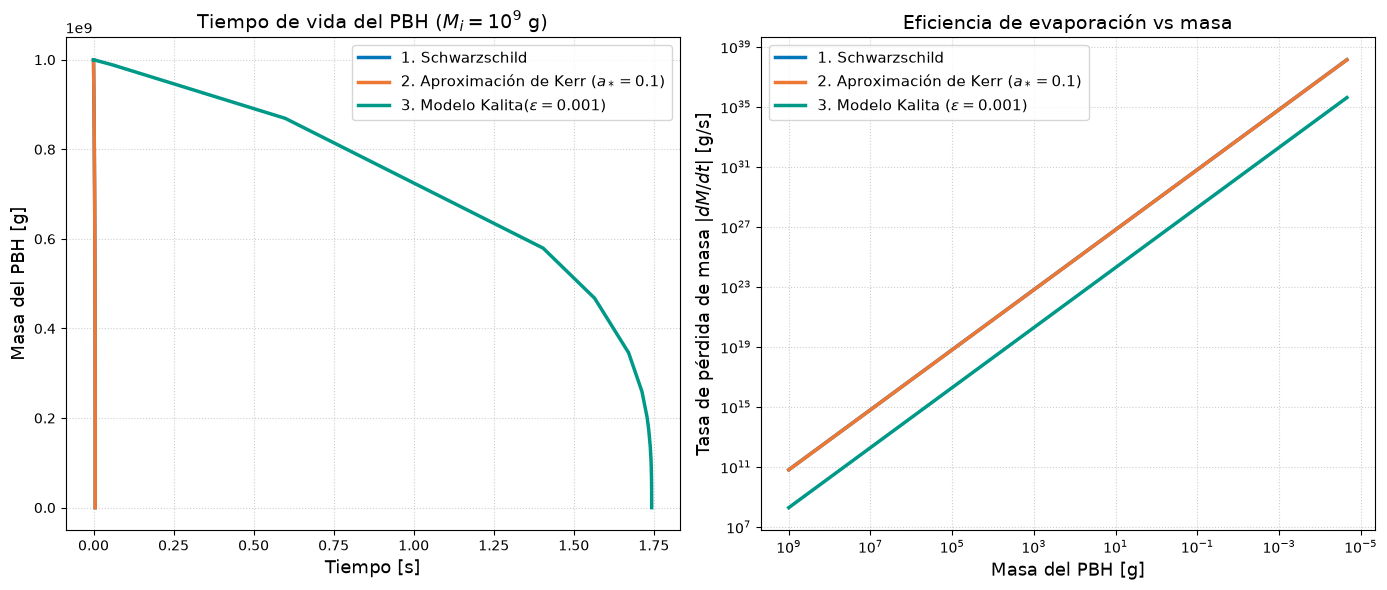

In [3]:
from scipy.integrate import solve_ivp

# Constantes en CGS
M_pl_g = 2.17645e-5
t_pl_s = 5.391247e-44

def comparar_evaporacion(M_i_g=1e9, a_star=0.9):
    # 1. Transformación a unidades de Planck para integración estable
    M_i_pl = M_i_g / M_pl_g
    
    # 2. Factores de los modelos
    # Modelo Kerr Geométrico
    a_safe = np.clip(a_star, 0.0, 0.9999)
    raiz_espin = np.sqrt(1.0 - a_safe**2)
    factor_T = (2.0 * raiz_espin) / (1.0 + raiz_espin)
    factor_A = 0.5 * (1.0 + raiz_espin)
    factor_kerr = (factor_T**4) * factor_A
    
    # Eficiencia de evaporación para el modelo de Kalita
    epsilon = 1e-3

    def rhs_sch(t, M): return [-1.0 / (3.0 * M[0]**2)]
    def rhs_kerr(t, M): return [-(1.0 / 3.0) * factor_kerr / M[0]**2]
    def rhs_usr(t, M): return [-epsilon / M[0]**2]
    
    def evento_fin(t, M): return M[0] - 1.1
    evento_fin.terminal = True
    
    # 4. Integración dinámica calculando un t_max adecuado
    t_max_pl = (M_i_pl**3) / (3.0 * min(epsilon, factor_kerr/3.0, 1.0/3.0)) * 1.5
    
    sol_sch = solve_ivp(rhs_sch, [0, t_max_pl], [M_i_pl], events=evento_fin)
    sol_kerr = solve_ivp(rhs_kerr, [0, t_max_pl], [M_i_pl], events=evento_fin)
    sol_usr = solve_ivp(rhs_usr, [0, t_max_pl], [M_i_pl], events=evento_fin)
    
    # 5. Graficación
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Panel 1: Evolución de la Masa en el tiempo ---
    ax1.plot(sol_sch.t * t_pl_s, sol_sch.y[0] * M_pl_g, label='1. Schwarzschild', lw=2.5, color='#0077BB')
    ax1.plot(sol_kerr.t * t_pl_s, sol_kerr.y[0] * M_pl_g, label=rf'2. Aproximación de Kerr ($a_*={a_star}$)', lw=2.5, color='#EE7733')
    ax1.plot(sol_usr.t * t_pl_s, sol_usr.y[0] * M_pl_g, label=rf'3. Modelo Kalita($\epsilon={epsilon}$)', lw=2.5, color='#009988')
    
    ax1.set_xlabel('Tiempo [s]', fontsize=13)
    ax1.set_ylabel('Masa del PBH [g]', fontsize=13)
    ax1.set_title(f'Tiempo de vida del PBH ($M_i = 10^{{{int(np.log10(M_i_g))}}}$ g)', fontsize=14)
    ax1.grid(True, ls=':', alpha=0.6)
    ax1.legend(fontsize=11)
    
    # --- Panel 2: Tasa de evaporación ---
    M_arr_pl = np.logspace(0, np.log10(M_i_pl), 500)
    M_arr_g = M_arr_pl * M_pl_g
    
    rate_sch = (1.0 / (3.0 * M_arr_pl**2)) * (M_pl_g / t_pl_s)
    rate_kerr = ((1.0 / 3.0) * factor_kerr / M_arr_pl**2) * (M_pl_g / t_pl_s)
    rate_usr = (epsilon / M_arr_pl**2) * (M_pl_g / t_pl_s)
    
    ax2.plot(M_arr_g, rate_sch, label='1. Schwarzschild', lw=2.5, color='#0077BB')
    ax2.plot(M_arr_g, rate_kerr, label=rf'2. Aproximación de Kerr ($a_*={a_star}$)', lw=2.5, color='#EE7733')
    ax2.plot(M_arr_g, rate_usr, label=rf'3. Modelo Kalita ($\epsilon={epsilon}$)', lw=2.5, color='#009988')
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Masa del PBH [g]', fontsize=13)
    ax2.set_ylabel(r'Tasa de pérdida de masa $|dM/dt|$ [g/s]', fontsize=13)
    ax2.set_title('Eficiencia de evaporación vs masa', fontsize=14)
    ax2.invert_xaxis() 
    ax2.grid(True, which='both', ls=':', alpha=0.6)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_evaporacion(M_i_g=1e9, a_star=0.1)

1/3 - Generando espacio de masas...
2/3 - Evaluando modelo Estándar (SBB) base...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscorr.py:543: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)


3/3 - Calculando acreción y trazando comparativa...
      -> Procesando lambda = 0.5
      -> Procesando lambda = 1.5
      -> Procesando lambda = 2.5


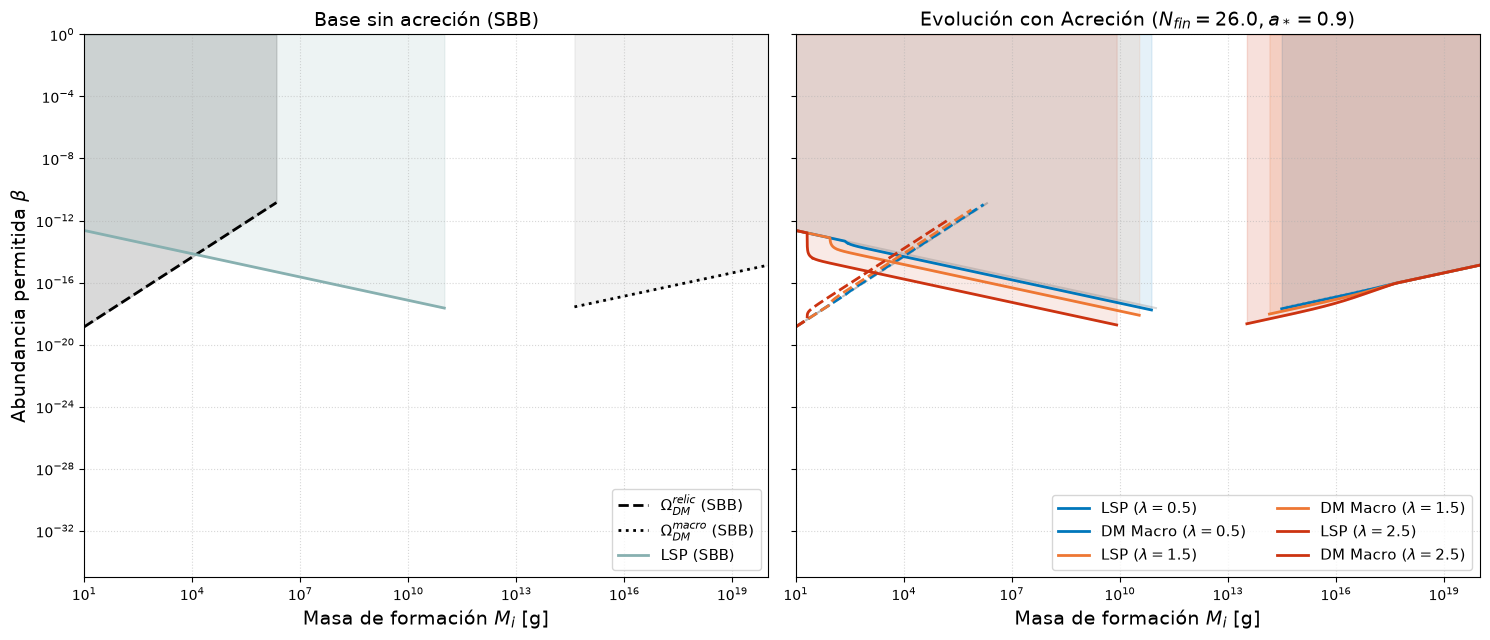

In [3]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    # Limpiamos el resto por seguridad aunque no se usen aquí
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def clean_beta(b):
    """Enmascara los valores inválidos (ev1) con NaN para matplotlib."""
    return np.where(b == constants.ev1, np.nan, b)

def graficar_eficiencias_dm_lsp():
    print("1/3 - Generando espacio de masas...")
    # Aseguramos el límite superior en 1e22 para evitar cortes por extrapolación
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    omega = 1.0/3.0
    N_fin = 26.0
    a_star = 0.9
    
    # Arreglo de eficiencias de acreción a explorar
    lam_lista = [0.5, 1.5, 2.5]
    colores_acc = ['#0077BB', '#EE7733', '#CC3311']
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/3 - Evaluando modelo Estándar (SBB) base...")
    limpiar_memoria()
    
    fn_comp.Betas_DM(M_tot, omega)
    fn_comp.Betas_LSP(M_tot, omega)
    
    b_dm_std = np.array(fn_comp.constraints.betas_DM_tot)
    b_lsp_std = np.array(fn_comp.constraints.betas_LSP_tot)
    
    # Separación visual para el SBB
    mask_relic_std = M_tot <= 1e11 * constants.M_pl_g
    mask_macro_std = M_tot > 4.1e14
    b_relic_std = np.where(mask_relic_std, b_dm_std, constants.ev1)
    b_macro_std = np.where(mask_macro_std, b_dm_std, constants.ev1)

    # ---------------------------------------------------------
    # 2. CONFIGURACIÓN DEL PANEL DE GRÁFICAS
    # ---------------------------------------------------------
    print("3/3 - Calculando acreción y trazando comparativa...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
    
    # Función auxiliar de ploteo
    def plot_y_sombrear(ax, y_arr, color, label, linestyle='-', alpha_fill=0.15):
        y_clean = clean_beta(y_arr)
        mask = ~np.isnan(y_clean)
        if np.any(mask):
            line, = ax.plot(M_tot, y_clean, color=color, label=label, linestyle=linestyle, lw=2.0)
            ax.fill_between(M_tot, y_clean, 1.0, where=mask, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR SBB ---
    ax1.set_title("Base sin acreción (SBB)", fontsize=14)
    plot_y_sombrear(ax1, b_relic_std, 'black', r'$\Omega_{DM}^{relic}$ (SBB)', linestyle='--')
    plot_y_sombrear(ax1, b_macro_std, 'black', r'$\Omega_{DM}^{macro}$ (SBB)', linestyle=':', alpha_fill=0.05)
    plot_y_sombrear(ax1, b_lsp_std, '#87B0B0', 'LSP (SBB)')

    # --- PANEL DERECHO: COMPARATIVA POR LAMBDA ---
    ax2.set_title(rf"Evolución con Acreción ($N_{{fin}} = {N_fin}, a_* = {a_star}$)", fontsize=14)
    
    # Trazamos la sombra tenue del SBB como referencia de fondo
    ax2.plot(M_tot, clean_beta(b_relic_std), color='grey', linestyle='--', alpha=0.5)
    ax2.plot(M_tot, clean_beta(b_macro_std), color='grey', linestyle=':', alpha=0.5)
    ax2.plot(M_tot, clean_beta(b_lsp_std), color='grey', alpha=0.3)
    
    for idx, lam in enumerate(lam_lista):
        print(f"      -> Procesando lambda = {lam}")
        
        # Integración JAX
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, float(N_fin), float(a_star), lam=lam)
        M_f_tot = np.maximum.accumulate(np.array(M_f_tot_jnp))
        
        # Corrimiento
        b_dm_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_dm_std)
        b_lsp_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_lsp_std)
        
        # Separación DM para el lambda actual
        mask_relic_acc = M_f_tot <= 1e11 * constants.M_pl_g
        mask_macro_acc = M_f_tot > 4.1e14
        b_relic_acc = np.where(mask_relic_acc, b_dm_acc, constants.ev1)
        b_macro_acc = np.where(mask_macro_acc, b_dm_acc, constants.ev1)
        
        # Trazado en el panel derecho
        color_lam = colores_acc[idx]
        # Dibujamos LSP
        plot_y_sombrear(ax2, b_lsp_acc, color_lam, rf'LSP ($\lambda={lam}$)', alpha_fill=0.1)
        # Dibujamos DM macroscópica (las reliquias se solapan así que evitamos leyenda redundante)
        plot_y_sombrear(ax2, b_macro_acc, color_lam, rf'DM Macro ($\lambda={lam}$)', linestyle='-')
        # Trazamos las reliquias en el mismo color sin etiqueta para mantener limpio
        y_relic_clean = clean_beta(b_relic_acc)
        if np.any(~np.isnan(y_relic_clean)):
            ax2.plot(M_tot, y_relic_clean, color=color_lam, linestyle='--', lw=2.0)

    # --- FORMATO GLOBAL ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'Masa de formación $M_i$ [g]', fontsize=14)
        ax.set_xlim(1e1, 1e20)
        ax.set_ylim(1e-35, 1e0)
        ax.grid(True, which='both', ls=':', alpha=0.5)
    
    ax1.set_ylabel(r'Abundancia permitida $\beta$', fontsize=14)
    
    # Leyendas independientes para claridad
    ax1.legend(loc='lower right', fontsize=11)
    ax2.legend(loc='lower right', fontsize=11, ncol=2)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    graficar_eficiencias_dm_lsp()

In [9]:
import numpy as np
from scipy.optimize import minimize_scalar

def calcular_lambda_critico(a_star, Omega_phi, M_H_pl, mu_pl):
    """
    Calcula el valor numérico exacto de lambda crítico para cualquier escenario.
    
    Parámetros:
    a_star    : Espín del PBH [0.0 a 1.0)
    Omega_phi : Fracción de densidad del campo escalar de fondo (<= 1.0)
    M_H_pl    : Masa del horizonte de Hubble en unidades de Planck
    mu_pl     : Masa del campo escalar en unidades de Planck
    """
    # 1. Calcular el factor de reducción geométrica por espín f(a_*)
    f_a = ((1.0 + np.sqrt(1.0 - a_star**2.0)) / 2.0)**2.0
    
    # Constante para la supresión cuántica (C = 2 * M_H * mu_pl)
    C = 2.0 * M_H_pl * mu_pl
    
    # 2. Definir la función G(x) que gobierna el perfil de acreción
    def G(x):
        # Término cuántico S_onda evaluado en x
        S_onda = (C**2.0 * x**2.0) / (1.0 + C**2.0 * x**2.0)
        # Perfil completo
        return S_onda * x * (1.0 - x)
        
    # Como queremos MAXIMIZAR G(x), le pedimos a SciPy que minimice -G(x)
    def neg_G(x):
        return -G(x)
        
    # Buscar el pico exacto numéricamente en el intervalo físico x in [0, 1]
    res = minimize_scalar(neg_G, bounds=(0.0, 1.0), method='bounded')
    
    if not res.success:
        raise ValueError("Error numérico: No se pudo encontrar el máximo de G(x).")
        
    x_max = res.x
    G_max = -res.fun  # Recuperamos el valor positivo del máximo
    
    # 3. Calcular la eficiencia termodinámica exigida (lambda crítico)
    lambda_c = 0.5 / (f_a * Omega_phi * G_max)
    
    return lambda_c, x_max, G_max

# =====================================================================
# PRUEBAS DEL MODELO
# =====================================================================
if __name__ == "__main__":
    
    # CASO 1: El Límite Clásico Ideal (Debe dar exactamente 2.0 en x=0.5)
    # Sin espín, densidad total, y un PBH tan gigante que S_onda -> 1
    lam_c_ideal, x_ideal, G_ideal = calcular_lambda_critico(
        a_star=0.0, Omega_phi=1.0, M_H_pl=1e15, mu_pl=1.0
    )
    print("--- CASO 1: Límite Clásico Ideal ---")
    print(f"Pico de acreción en x = {x_ideal:.4f}")
    print(f"G_max = {G_ideal:.4f}")
    print(f"Lambda Crítico = {lam_c_ideal:.4f}\n")
    
    # CASO 2: Régimen Cuántico y Relativista
    # Espín moderado (a=0.9), universo ligeramente diluido (Omega=0.95),
    # y un horizonte pequeño donde la difracción importa (M_H pequeño)
    lam_c_real, x_real, G_real = calcular_lambda_critico(
        a_star=0.9, Omega_phi=0.4, M_H_pl=10.0, mu_pl=0.1
    )
    print("--- CASO 2: Agujero Negro con Espín en Régimen Cuántico ---")
    print(f"Pico de acreción desplazado a x = {x_real:.4f}")
    print(f"G_max suprimido = {G_real:.4f}")
    print(f"Lambda Crítico exigido = {lam_c_real:.4f}")

--- CASO 1: Límite Clásico Ideal ---
Pico de acreción en x = 0.5000
G_max = 0.2500
Lambda Crítico = 2.0000

--- CASO 2: Agujero Negro con Espín en Régimen Cuántico ---
Pico de acreción desplazado a x = 0.6378
G_max suprimido = 0.1431
Lambda Crítico exigido = 16.9493
